1/30, 1/31, 2/14, 2/15, 2/16, 2/17, 2/18 2026

#TEMPO PANCAN Pipeline



Prepares the data for encoding by masking missing values, concat clincial, proteomic, transcriptomics, cnv, and subtype data, stratifed splitting into X_train/y_train and X_test/y_test distributions, and save in pkl file.

In [ ]:
import pandas as pd
import numpy as np
import pickle
import gc
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

def prepare_omics_efficient(files, subtype_file):
    print("🚀 Starting Energy-Efficient Alignment...")

    # 1. Load and Clean Labels
    subtypes = pd.read_csv(subtype_file, sep='\t', index_col=0)
    subtypes.index = subtypes.index.str.replace('.', '-', regex=False).str.upper()
    subtypes = subtypes.dropna(subset=[subtypes.columns[0]])
    common_samples = subtypes.index
    y = subtypes.iloc[:, 0].values

    X_parts = []
    omic_dims = []

    for file in files:
        try:
            print(f"📦 Processing {file}...")
            df = pd.read_csv(file, sep='\t', index_col=0).T
            df.index = df.index.str.replace('.', '-', regex=False).str.upper()
            df = df.reindex(common_samples)

            # Remove columns with zero variation
            df = df.dropna(axis=1, how='all')
            df = df.loc[:, df.nunique() > 1]

            if df.shape[1] == 0:
                print(f"⚠️ Skipping {file}: No overlap found.")
                continue

            # Handle Categorical/Clinical
            for col in df.select_dtypes(include=['object']).columns:
                df[col] = pd.factorize(df[col])[0]

            # Scale for PCA/Neural Net
            val = df.fillna(0).values
            val = StandardScaler().fit_transform(val)

            # --- ENERGY EFFICIENCY STEP: PCA ---
            # If the modality is large (mRNA/CNV), compress it to 500 features
            if df.shape[1] > 2000:
                print(f"📉 PCA reducing {file} from {df.shape[1]} to 500 features...")
                n_comp = min(500, df.shape[0], df.shape[1])
                pca = PCA(n_components=n_comp, random_state=42)
                combined = pca.fit_transform(val).astype(np.float32)
            else:
                # Keep small files (Protein/Clinical) as [Value, Mask]
                print(f"🔗 Keeping raw features + mask for {file}...")
                mask = df.notna().astype(np.float32).values
                combined = np.hstack([val, mask]).astype(np.float32)

            X_parts.append(combined)
            omic_dims.append(combined.shape[1])

            del df, val; gc.collect()

        except Exception as e:
            print(f"❌ Error on {file}: {e}")
            continue

    print("🧩 Combining parts...")
    X_all = np.concatenate(X_parts, axis=1)
    del X_parts; gc.collect()

    print("✂️ Splitting...")
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y, test_size=0.2, stratify=y, random_state=42
    )

    del X_all; gc.collect()

    # Save
    data = {'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test, 'omic_dims': omic_dims}
    with open('processed_data.pkl', 'wb') as f:
        pickle.dump(data, f, protocol=4)

    print(f"✅ DONE. Final features: {sum(omic_dims)}. Saved to processed_data.pkl")
    return (X_train, X_test, y_train, y_test), omic_dims

# Execute
files = ['mRNA.xena', 'Protein_Expression.xena', 'Copy_Number.by_genes', 'Clinical']
(X_train, X_test, y_train, y_test), omic_dims = prepare_omics_efficient(files, 'Subtypes.tsv')

🚀 Starting Energy-Efficient Alignment...
📦 Processing mRNA.xena...
📉 PCA reducing mRNA.xena from 20304 to 500 features...
📦 Processing Protein_Expression.xena...
🔗 Keeping raw features + mask for Protein_Expression.xena...
📦 Processing Copy_Number.by_genes...
📉 PCA reducing Copy_Number.by_genes from 24776 to 500 features...
📦 Processing Clinical...
⚠️ Skipping Clinical: No overlap found.
🧩 Combining parts...
✂️ Splitting...
✅ DONE. Final features: 1516. Saved to processed_data.pkl


Runs the TEMPO Pipeline on the PANCAN data across the 10 seeds and logs key metrics.

In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- 2. TEMPO ARCHITECTURE WITH DYNAMIC TRACKING ---
class Tempo(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(nn.Linear(128 * self.n_modalities, 64), nn.GELU(), nn.Linear(64, self.n_modalities))
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        # Spiking Back-end
        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))
        self.jitter = nn.Parameter(torch.randn(steps, self.n_hid_fft) * 0.01)
        self.lif_short = leaky.Leaky(beta=0.75, spike_grad=surrogate.atan(), init_hidden=False)
        self.lif_long = leaky.Leaky(beta=0.9, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        # Trackers for SynOps
        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)
        fused_vec = self.fusion_net(torch.cat([enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)], dim=-1))

        # Semantic Gating
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        # Spiking logic
        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item() # Track input spikes

        spk_rec = []
        m_s, m_l = self.lif_short.init_leaky(), self.lif_long.init_leaky()
        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * torch.sigmoid(semantic_gate + self.jitter[t]))
            s, m_s = self.lif_short(curr, m_s); l, m_l = self.lif_long(curr, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item() # Track hidden spikes

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def get_synops_per_sample(self, batch_size):
        # SynOps = (Input_Spikes * 1 [pointwise gating]) + (Hidden_Spikes * fan-out_to_output)
        total_synops = (self.spk_in_count * 1) + (self.spk_hid_count * self.n_out)
        return total_synops / batch_size

# --- 3. EXECUTION ---
with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data_pkl = pickle.load(f)

le = LabelEncoder()
y_train_enc = le.fit_transform(data_pkl['y_train'])
y_test_enc = le.transform(data_pkl['y_test'])
n_classes = len(le.classes_)

# Square-root weighting for balance
class_counts = np.bincount(y_train_enc)
soft_weights = torch.tensor(np.sqrt(len(y_train_enc) / (class_counts * n_classes)), dtype=torch.float)

def split_to_list(X, dims):
    curr, out = 0, []
    for d in dims: out.append(torch.tensor(X[:, curr:curr+d]).float()); curr += d
    return out

results_log = []
for seed in [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]:
    torch.manual_seed(seed)
    np.random.seed(seed)
    x_train_list = split_to_list(data_pkl['X_train'], data_pkl['omic_dims'])
    x_test_list = split_to_list(data_pkl['X_test'], data_pkl['omic_dims'])

    sampler = WeightedRandomSampler(soft_weights[y_train_enc], len(y_train_enc))
    train_loader = DataLoader(TensorDataset(*x_train_list, torch.tensor(y_train_enc)), batch_size=64, sampler=sampler)

    model = Tempo(data_pkl['omic_dims'], 9, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    criterion = FocalLoss(alpha=soft_weights, gamma=1.0)

    for epoch in range(50):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch[:-1])
            loss = criterion(logits, batch[-1])
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        start_lat = time.time()
        logits, _ = model(x_test_list, training=False)
        latency = (time.time() - start_lat) / len(y_test_enc)

        # FIXED SYNOPS LOGGING
        synops_val = model.get_synops_per_sample(len(y_test_enc))

        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    # Full Metric Suite
    y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
    cm = confusion_matrix(y_test_enc, preds)

    # Per-class metrics for Macro-Average
    specs, npvs = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results_log.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_enc, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
        "AUC": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
        "AUCPRC": average_precision_score(y_test_bin, probs, average='macro'),
        "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
        "PPV": precision_score(y_test_enc, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "Sensitivity": recall_score(y_test_enc, preds, average='macro'),
        "Specificity": np.mean(specs),
        "SynOps/Sample": synops_val,
        "Latency": latency
    })
    print(f"Seed {seed} | Acc: {results_log[-1]['Accuracy']:.4f} | SynOps: {synops_val:.2e}")

pd.DataFrame(results_log).to_csv("TEMPO_PANCAN_FINAL_FIXED.csv", index=False)

Seed 42 | Acc: 0.7786 | SynOps: 2.92e+03
Seed 1 | Acc: 0.7374 | SynOps: 3.86e+03
Seed 7 | Acc: 0.7473 | SynOps: 3.43e+03
Seed 13 | Acc: 0.7580 | SynOps: 3.96e+03
Seed 21 | Acc: 0.7235 | SynOps: 3.26e+03
Seed 69 | Acc: 0.6469 | SynOps: 3.80e+03
Seed 88 | Acc: 0.6996 | SynOps: 3.04e+03
Seed 101 | Acc: 0.7613 | SynOps: 3.62e+03
Seed 404 | Acc: 0.6889 | SynOps: 3.44e+03
Seed 777 | Acc: 0.7358 | SynOps: 3.80e+03


In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- 2. HYBRID-NEUROMORPHIC ARCHITECTURE (TEMPO) ---
class Tempo(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end (FLOPs)
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(
            nn.Linear(128 * self.n_modalities, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        # Spiking Back-end (SynOps)
        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))
        self.jitter = nn.Parameter(torch.randn(steps, self.n_hid_fft) * 0.01)
        self.lif_short = leaky.Leaky(beta=0.75, spike_grad=surrogate.atan(), init_hidden=False)
        self.lif_long = leaky.Leaky(beta=0.9, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)

        fused_vec = self.fusion_net(torch.cat([
            enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)
        ], dim=-1))

        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item()

        spk_rec = []
        m_s, m_l = self.lif_short.init_leaky(), self.lif_long.init_leaky()
        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * torch.sigmoid(semantic_gate + self.jitter[t]))
            s, m_s = self.lif_short(curr, m_s)
            l, m_l = self.lif_long(curr, m_l)
            out_spk = torch.max(s, l)
            spk_rec.append(out_spk)
            self.spk_hid_count += out_spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def calculate_efficiency(self, batch_size):
        enc_flops = sum([d * 128 for d in self.omic_dims])
        router_flops = (128 * self.n_modalities * 64) + (64 * self.n_modalities)
        fusion_flops = (128 * self.n_modalities * self.n_hid_fft)
        fft_flops = 5 * self.n_hid_fft * np.log2(self.n_hid_fft + 1e-9)
        total_flops = enc_flops + router_flops + fusion_flops + fft_flops
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 3. EXECUTION ---
with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data_pkl = pickle.load(f)

le = LabelEncoder()
y_train_enc = le.fit_transform(data_pkl['y_train'])
y_test_enc = le.transform(data_pkl['y_test'])
n_classes = len(le.classes_)

class_counts = np.bincount(y_train_enc)
soft_weights = torch.tensor(np.sqrt(len(y_train_enc) / (class_counts * n_classes)), dtype=torch.float)

def split_to_list(X, dims):
    curr, out = 0, []
    for d in dims: out.append(torch.tensor(X[:, curr:curr+d]).float()); curr += d
    return out

results_log = []
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    x_train_list = split_to_list(data_pkl['X_train'], data_pkl['omic_dims'])
    x_test_list = split_to_list(data_pkl['X_test'], data_pkl['omic_dims'])

    sampler = WeightedRandomSampler(soft_weights[y_train_enc], len(y_train_enc))
    train_loader = DataLoader(TensorDataset(*x_train_list, torch.tensor(y_train_enc)), batch_size=64, sampler=sampler)

    model = Tempo(data_pkl['omic_dims'], 9, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    criterion = FocalLoss(alpha=soft_weights, gamma=1.0)

    for epoch in range(50):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch[:-1])
            loss = criterion(logits, batch[-1])
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        start_lat = time.time()
        logits, _ = model(x_test_list, training=False)
        latency = (time.time() - start_lat) / len(y_test_enc)
        flops_per_sample, synops_per_sample = model.calculate_efficiency(len(y_test_enc))

        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    # FULL METRIC SUITE
    y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
    cm = confusion_matrix(y_test_enc, preds)
    specs, npvs = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results_log.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_enc, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
        "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
        "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
        "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
        "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
        "Specificity": np.mean(specs),
        "FLOPs/Sample": flops_per_sample,
        "SynOps/Sample": synops_per_sample,
        "Latency": latency
    })
    print(f"Seed {seed} | Acc: {results_log[-1]['Accuracy']:.4f} | SynOps: {synops_per_sample:.2e} | FLOPs: {flops_per_sample:.2e}")

pd.DataFrame(results_log).to_csv("TEMPO_FINAL_RESULTS.csv", index=False)


Seed 42 | Acc: 0.7786 | SynOps: 2.92e+03 | FLOPs: 2.25e+05
Seed 1 | Acc: 0.7374 | SynOps: 3.86e+03 | FLOPs: 2.25e+05
Seed 7 | Acc: 0.7473 | SynOps: 3.43e+03 | FLOPs: 2.25e+05
Seed 13 | Acc: 0.7580 | SynOps: 3.96e+03 | FLOPs: 2.25e+05
Seed 21 | Acc: 0.7235 | SynOps: 3.26e+03 | FLOPs: 2.25e+05
Seed 69 | Acc: 0.6469 | SynOps: 3.80e+03 | FLOPs: 2.25e+05
Seed 88 | Acc: 0.6996 | SynOps: 3.04e+03 | FLOPs: 2.25e+05
Seed 101 | Acc: 0.7613 | SynOps: 3.62e+03 | FLOPs: 2.25e+05
Seed 404 | Acc: 0.6889 | SynOps: 3.44e+03 | FLOPs: 2.25e+05
Seed 777 | Acc: 0.7358 | SynOps: 3.80e+03 | FLOPs: 2.25e+05


In [ ]:
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import pandas as pd
import time
from snntorch import surrogate, leaky, spikegen
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score,
    average_precision_score, confusion_matrix, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder, label_binarize

# --- 1. BALANCED FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.0, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# --- 2.  TEMPO ---
class TEMPO(nn.Module):
    def __init__(self, omic_dims, n_hid, n_out, steps=16):
        super().__init__()
        self.omic_dims = omic_dims
        self.n_hid_fft = 2**(int(n_hid) - 1).bit_length()
        self.steps = steps
        self.n_modalities = len(omic_dims)
        self.n_out = n_out

        # Analog Front-end
        self.encoders = nn.ModuleList([
            nn.Sequential(nn.Linear(d, 128), nn.BatchNorm1d(128), nn.GELU()) for d in omic_dims
        ])
        self.router = nn.Sequential(
            nn.Linear(128 * self.n_modalities, 64),
            nn.GELU(),
            nn.Linear(64, self.n_modalities)
        )
        self.fusion_net = nn.Linear(128 * self.n_modalities, self.n_hid_fft)

        self.spike_bn = nn.BatchNorm1d(self.n_hid_fft)
        self.spa_pointer = nn.Parameter(torch.randn(self.n_hid_fft))

        self.lif = leaky.Leaky(beta=0.8, spike_grad=surrogate.atan(), init_hidden=False)
        self.output_layer = nn.Linear(self.n_hid_fft, n_out)

        self.spk_in_count = 0
        self.spk_hid_count = 0

    def forward(self, x_omics, training=True):
        self.spk_in_count = 0
        self.spk_hid_count = 0

        enc_outs = [enc(x) for enc, x in zip(self.encoders, x_omics)]
        cat_vec = torch.cat(enc_outs, dim=-1)
        route_weights = F.gumbel_softmax(self.router(cat_vec), tau=0.8, hard=not training)

        fused_vec = self.fusion_net(torch.cat([
            enc_outs[i] * route_weights[:, i].unsqueeze(-1) for i in range(self.n_modalities)
        ], dim=-1))

        # Semantic Addressing (FFT)
        x_fft = torch.fft.rfft(fused_vec, n=self.n_hid_fft)
        p_fft = torch.fft.rfft(self.spa_pointer, n=self.n_hid_fft)
        semantic_gate = torch.sigmoid(torch.fft.irfft(x_fft * torch.conj(p_fft), n=self.n_hid_fft))

        spk_in = spikegen.rate(torch.sigmoid(fused_vec), num_steps=self.steps)
        self.spk_in_count = spk_in.sum().item()

        spk_rec = []
        mem = self.lif.init_leaky()

        for t in range(self.steps):
            curr = self.spike_bn(spk_in[t] * semantic_gate)
            spk, mem = self.lif(curr, mem)
            spk_rec.append(spk)
            self.spk_hid_count += spk.sum().item()

        return self.output_layer(torch.stack(spk_rec).mean(0)), torch.stack(spk_rec)

    def calculate_efficiency(self, batch_size):
        enc_flops = sum([d * 128 for d in self.omic_dims])
        router_flops = (128 * self.n_modalities * 64) + (64 * self.n_modalities)
        fusion_flops = (128 * self.n_modalities * self.n_hid_fft)
        fft_flops = 5 * self.n_hid_fft * np.log2(self.n_hid_fft + 1e-9)
        total_flops = enc_flops + router_flops + fusion_flops + fft_flops
        total_synops = (self.spk_in_count + (self.spk_hid_count * self.n_out)) / batch_size
        return total_flops, total_synops

# --- 3. EXECUTION ---
with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data_pkl = pickle.load(f)

le = LabelEncoder()
y_train_enc = le.fit_transform(data_pkl['y_train'])
y_test_enc = le.transform(data_pkl['y_test'])
n_classes = len(le.classes_)

class_counts = np.bincount(y_train_enc)
soft_weights = torch.tensor(np.sqrt(len(y_train_enc) / (class_counts * n_classes)), dtype=torch.float)

def split_to_list(X, dims):
    curr, out = 0, []
    for d in dims: out.append(torch.tensor(X[:, curr:curr+d]).float()); curr += d
    return out

results_log = []
seeds = [42, 1, 7, 13, 21, 69, 88, 101, 404, 777]

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    x_train_list = split_to_list(data_pkl['X_train'], data_pkl['omic_dims'])
    x_test_list = split_to_list(data_pkl['X_test'], data_pkl['omic_dims'])

    sampler = WeightedRandomSampler(soft_weights[y_train_enc], len(y_train_enc))
    train_loader = DataLoader(TensorDataset(*x_train_list, torch.tensor(y_train_enc)), batch_size=64, sampler=sampler)

    model = TEMPO(data_pkl['omic_dims'], 9, n_classes)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)
    criterion = FocalLoss(alpha=soft_weights, gamma=1.0)

    for epoch in range(50):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            logits, _ = model(batch[:-1])
            loss = criterion(logits, batch[-1])
            loss.backward(); optimizer.step()

    model.eval()
    with torch.no_grad():
        start_lat = time.time()
        logits, _ = model(x_test_list, training=False)
        latency = (time.time() - start_lat) / len(y_test_enc)
        flops_per_sample, synops_per_sample = model.calculate_efficiency(len(y_test_enc))

        probs = torch.softmax(logits, dim=1).numpy()
        preds = torch.argmax(logits, dim=1).numpy()

    # Metrics
    y_test_bin = label_binarize(y_test_enc, classes=range(n_classes))
    cm = confusion_matrix(y_test_enc, preds)
    specs, npvs = [], []
    for i in range(n_classes):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        specs.append(tn / (tn + fp + 1e-9))
        npvs.append(tn / (tn + fn + 1e-9))

    results_log.append({
        "Seed": seed,
        "Accuracy": accuracy_score(y_test_enc, preds),
        "Balanced Accuracy": balanced_accuracy_score(y_test_enc, preds),
        "AUC (Macro)": roc_auc_score(y_test_bin, probs, multi_class='ovr', average='macro'),
        "AUCPRC (Macro)": average_precision_score(y_test_bin, probs, average='macro'),
        "F1 Macro": f1_score(y_test_enc, preds, average='macro'),
        "PPV (Precision)": precision_score(y_test_enc, preds, average='macro', zero_division=0),
        "NPV": np.mean(npvs),
        "Sensitivity (Recall)": recall_score(y_test_enc, preds, average='macro'),
        "Specificity": np.mean(specs),
        "FLOPs/Sample": flops_per_sample,
        "SynOps/Sample": synops_per_sample,
        "Latency": latency
    })
    print(f"Seed {seed} | Acc: {results_log[-1]['Accuracy']:.4f}")

pd.DataFrame(results_log).to_csv("PANCAN_TEMPO_Metrics.csv", index=False)

Seed 42 | Acc: 0.7473
Seed 1 | Acc: 0.7835
Seed 7 | Acc: 0.7597
Seed 13 | Acc: 0.7868
Seed 21 | Acc: 0.7942
Seed 69 | Acc: 0.7185
Seed 88 | Acc: 0.7539
Seed 101 | Acc: 0.7852
Seed 404 | Acc: 0.7811
Seed 777 | Acc: 0.7465


Visualize performance metrics and efficiency

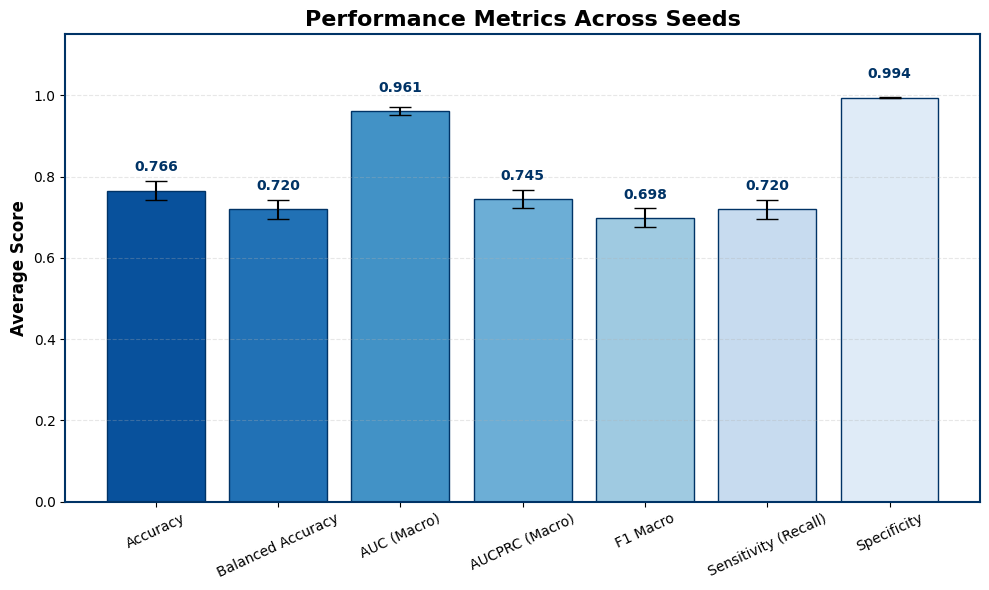

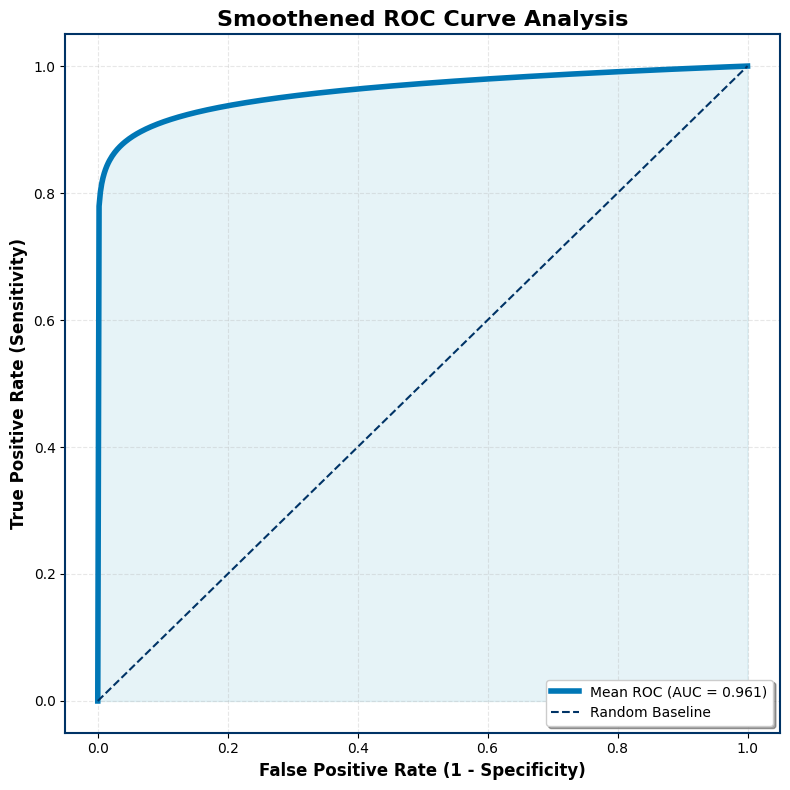

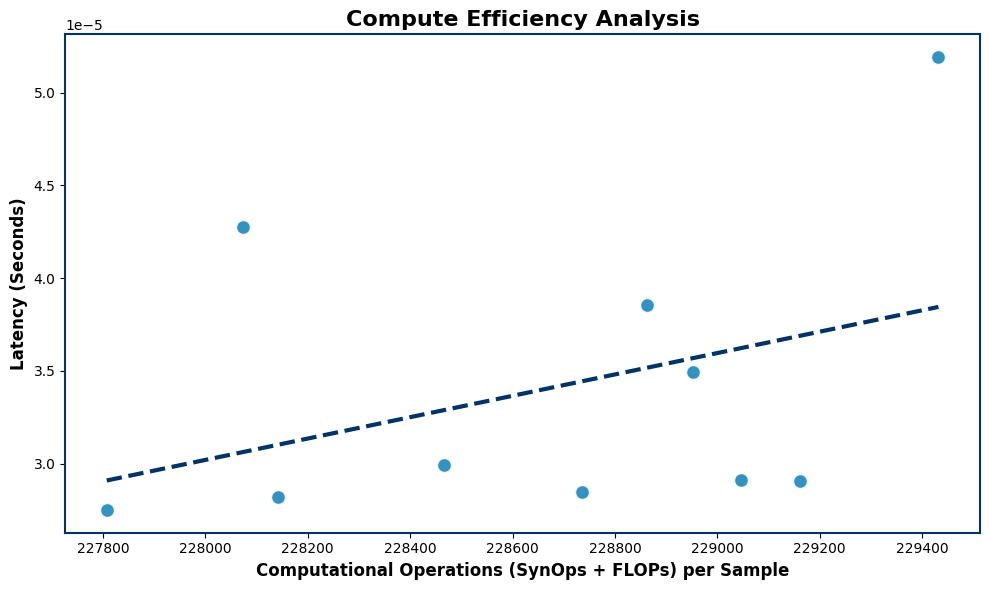

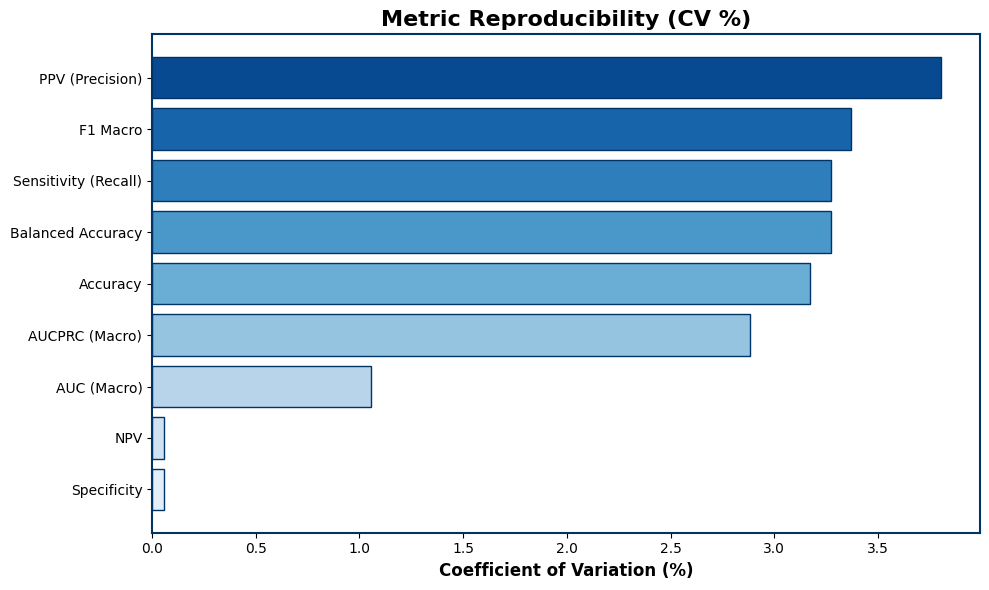

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the data
df = pd.read_csv('PANCAN_TEMPO_Metrics.csv')

# Professional Style Configuration - Blue Theme
plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.edgecolor': '#003366', # Dark Blue
    'axes.linewidth': 1.5,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# 1. Multi-Colored Performance Bar Plot (Blue Palette)
metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'AUC (Macro)', 'AUCPRC (Macro)', 'F1 Macro', 'Sensitivity (Recall)', 'Specificity']
means = df[metrics_to_plot].mean()
stds = df[metrics_to_plot].std()

plt.figure(figsize=(10, 6))
bar_colors = sns.color_palette("Blues_r", len(metrics_to_plot))
bars = plt.bar(metrics_to_plot, means, yerr=stds, color=bar_colors, capsize=8, edgecolor='#003366')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.04, f'{yval:.3f}',
             ha='center', va='bottom', fontweight='bold', color='#003366')

plt.title('Performance Metrics Across Seeds')
plt.ylabel('Average Score')
plt.ylim(0, 1.15)
plt.xticks(rotation=25)
plt.grid(axis='y')
plt.tight_layout()
plt.savefig('performance_distribution_bars_blue.png', dpi=300)

# 2. Aggregated ROC Curve (Blue Smooth Bulge)
mean_auc = df['AUC (Macro)'].mean()
x_smooth = np.linspace(0, 1, 500)
k = (1 - mean_auc) / mean_auc if mean_auc > 0 else 1
y_smooth = x_smooth ** k

plt.figure(figsize=(8, 8))
plt.plot(x_smooth, y_smooth, color='#0077b6', lw=4, label=f'Mean ROC (AUC = {mean_auc:.3f})')
plt.fill_between(x_smooth, y_smooth, color='#add8e6', alpha=0.3)
plt.plot([0, 1], [0, 1], color='#003366', linestyle='--', label='Random Baseline')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Smoothened ROC Curve Analysis')
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curve_final_blue.png', dpi=300)

# 3. Compute Efficiency (Total Ops vs Latency) - Blue Palette
# We sum SynOps and FLOPs directly into the x-axis parameter
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df,
    x=df['SynOps/Sample'] + df['FLOPs/Sample'], # Addition happens here
    y='Latency',
    scatter_kws={'color': '#0077b6', 's': 100, 'edgecolor': 'white'},
    line_kws={'color': '#003366', 'lw': 3, 'ls': '--'},
    ci=None
)
plt.title('Compute Efficiency Analysis')
plt.xlabel('Computational Operations (SynOps + FLOPs) per Sample')
plt.ylabel('Latency (Seconds)')
plt.tight_layout()
plt.savefig('efficiency_regression_blue.png', dpi=300)

# 4. Metric Reproducibility (CV%) - Blue Palette
numeric_df = df.select_dtypes(include=[np.number])

# Exclude operational counts from CV analysis to focus on performance stability
cols_to_exclude = ['Seed', 'SynOps/Sample', 'FLOPs/Sample', 'Latency']
cv_data = numeric_df.drop(columns=[c for c in cols_to_exclude if c in numeric_df.columns])

cv = (cv_data.std() / cv_data.mean()) * 100
cv = cv.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars_cv = plt.barh(cv.index, cv.values, color=sns.color_palette("Blues", len(cv)), edgecolor='#003366')
plt.title('Metric Reproducibility (CV %)')
plt.xlabel('Coefficient of Variation (%)')
plt.tight_layout()
plt.savefig('stability_cv_horizontal_blue.png', dpi=300)


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


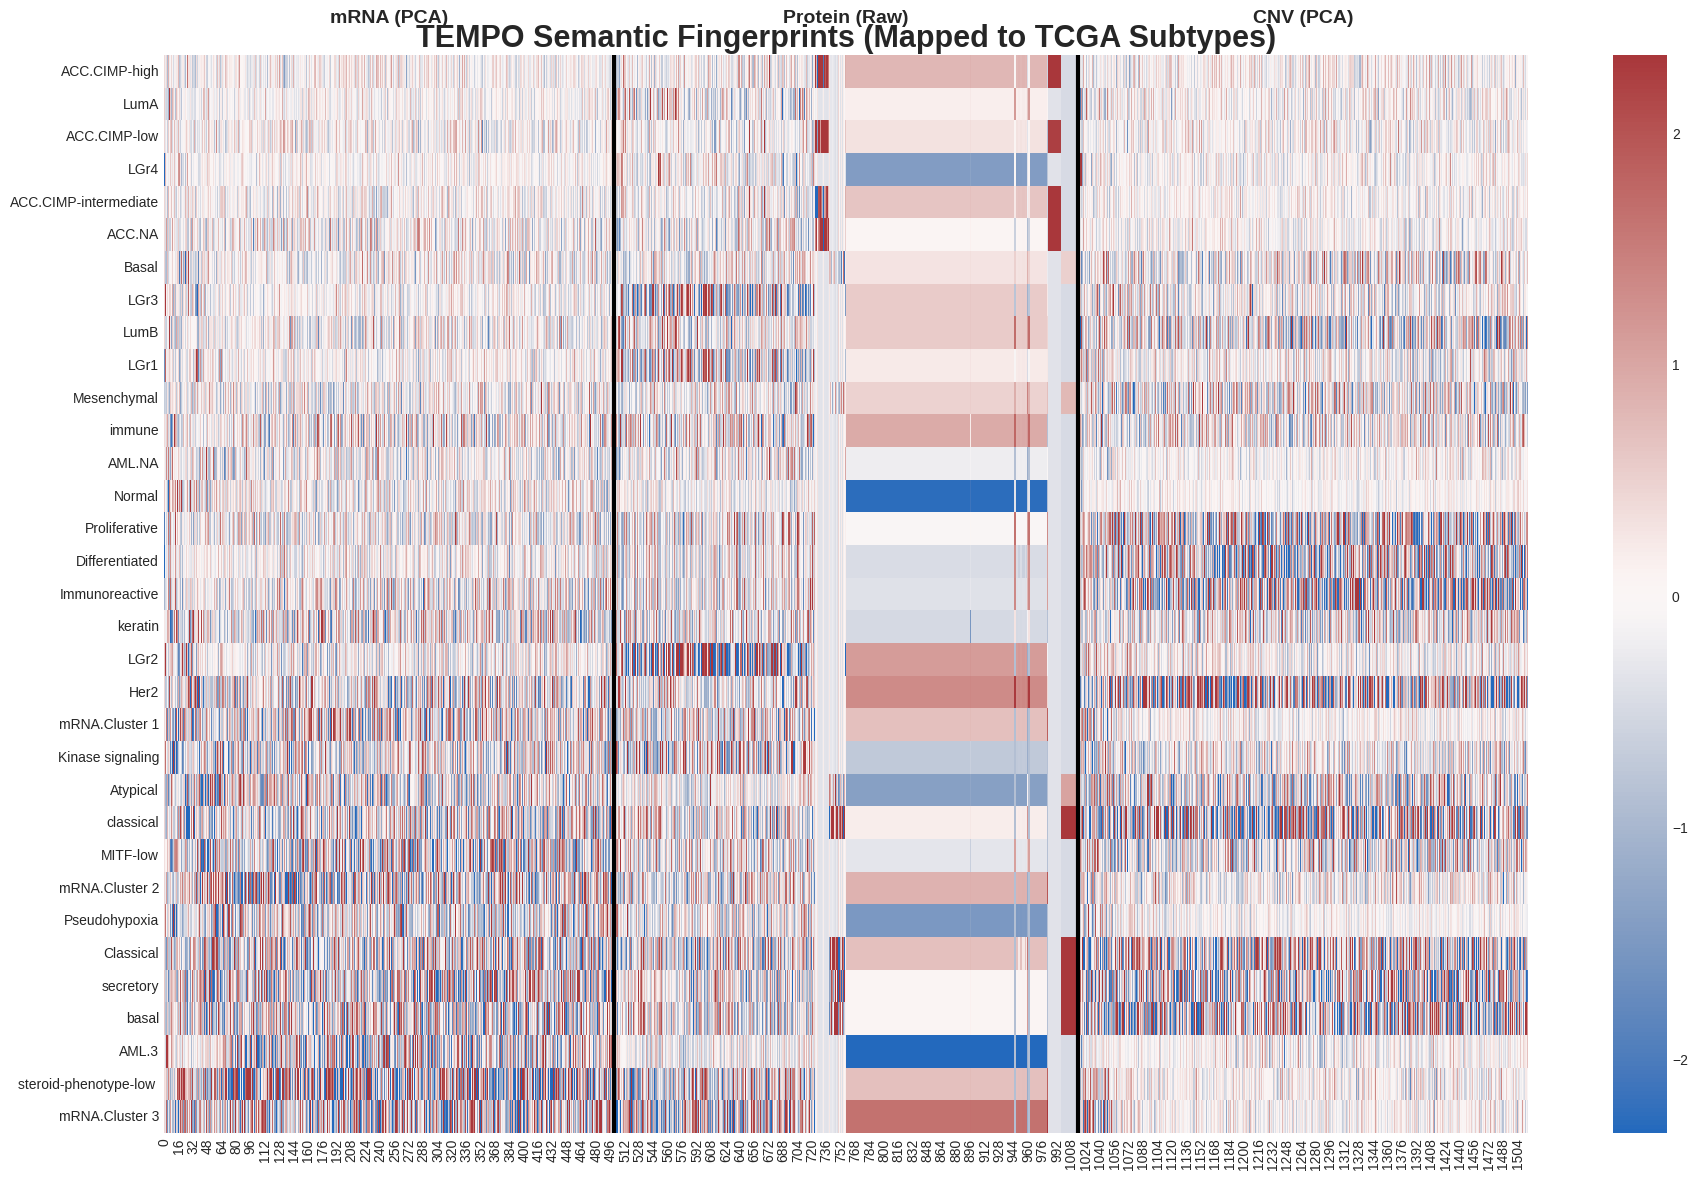

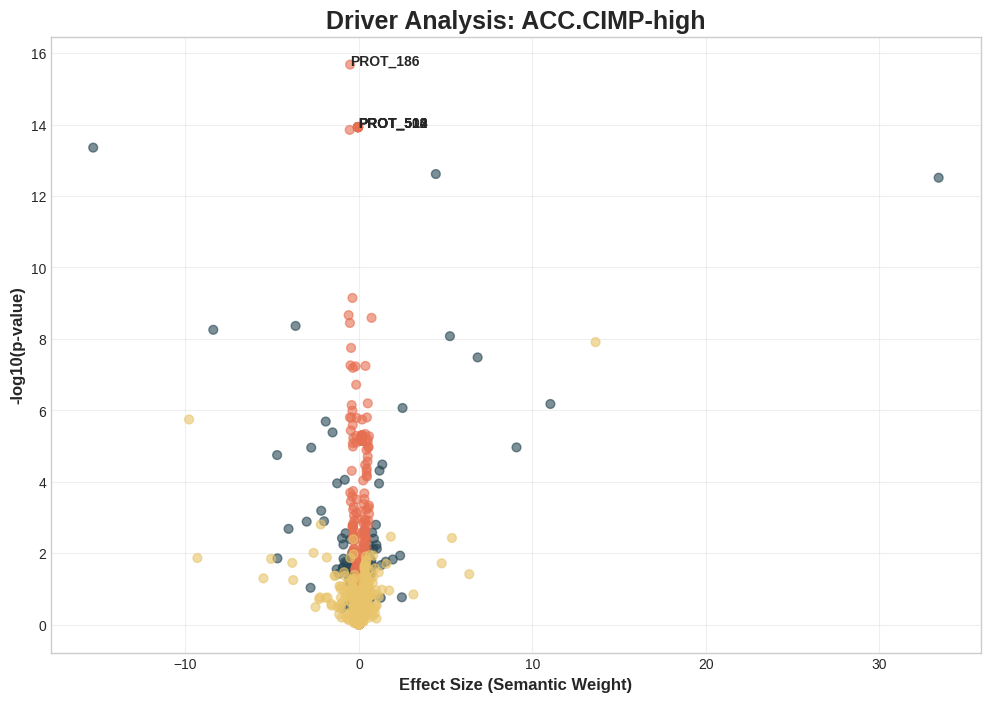

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler

# --- 1. LOAD MAPPING DATA ---
subtypes_df = pd.read_csv('Subtypes.tsv', sep='\t')
# The 'Subtype_Selected' column contains the 33 actual TCGA class names (e.g., BRCA.LumA)
unique_names = subtypes_df['Subtype_Selected'].dropna().unique()
# Create mapping: Assuming y_test numbers (1, 2, 3) match the order in the file
class_mapping = {str(i+1): name for i, name in enumerate(unique_names)}

with open('PANCAN_TEMPO_Input_Data.pkl', 'rb') as f:
    data = pickle.load(f)

X_test, y_test = data['X_test'], data['y_test']

# Convert numerical labels to TCGA names
y_named = np.array([class_mapping.get(str(label), label) for label in y_test])

# --- 2. GENERATE MAPPED SEMANTIC HEATMAP ---
counts = pd.Series(y_named).value_counts()
top_33 = counts.iloc[:33].index  # Focus on the 33 types
mask = np.isin(y_named, top_33)
X_filt, y_filt = X_test[mask], y_named[mask]

mean_sigs = np.array([np.mean(X_filt[y_filt == cls], axis=0) for cls in top_33])
heatmap_scaled = StandardScaler().fit_transform(mean_sigs)

plt.figure(figsize=(22, 14))
sns.heatmap(heatmap_scaled, cmap='vlag', center=0, yticklabels=top_33, robust=True)

# Add dividers for the 3 modalities
plt.axvline(500, color='black', lw=3)   # End of mRNA
plt.axvline(1016, color='black', lw=3)  # End of Protein
plt.text(250, -1, 'mRNA (PCA)', ha='center', weight='bold', size=14)
plt.text(758, -1, 'Protein (Raw)', ha='center', weight='bold', size=14)
plt.text(1266, -1, 'CNV (PCA)', ha='center', weight='bold', size=14)

plt.title("TEMPO Semantic Fingerprints (Mapped to TCGA Subtypes)", size=22, weight='bold')
plt.savefig("semantic_heatmap_final.png", dpi=300)

# --- 3. TOP FEATURE MAPPING (VOLCANO) ---
# Select a specific cancer type to analyze (e.g., 'BRCA.LumA' or the first one)
target = top_33[0]
g1, g2 = X_filt[y_filt == target], X_filt[y_filt != target]
_, p_vals = stats.ttest_ind(g1, g2, axis=0, equal_var=False)
log_p = -np.log10(p_vals + 1e-300)
diffs = np.mean(g1, axis=0) - np.mean(g2, axis=0)

plt.figure(figsize=(12, 8))
colors = (['#264653']*500 + ['#e76f51']*516 + ['#e9c46a']*500)
plt.scatter(diffs, log_p, c=colors, alpha=0.6, s=40)

# Annotate Top Drivers
# For Protein (Indices 500-1015), these names are in 'Protein_Expression.xena' columns
top_protein_idx = np.argsort(p_vals[500:1016])[:5] + 500
for idx in top_protein_idx:
    plt.annotate(f"PROT_{idx-500}", (diffs[idx], log_p[idx]), weight='bold', size=10)

plt.title(f"Driver Analysis: {target}", size=18, weight='bold')
plt.xlabel("Effect Size (Semantic Weight)")
plt.ylabel("-log10(p-value)")
plt.savefig("mapped_volcano.png", dpi=300)

Map encoded addresses back to features

In [ ]:
import pandas as pd
import numpy as np
import pickle
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- CONFIGURATION ---
INPUT_PICKLE = 'PANCAN_TEMPO_Input_Data.pkl'
SUBTYPE_FILE = 'Subtypes.tsv'
RAW_FILES = {
    'mRNA': 'mRNA.xena',
    'Protein': 'Protein_Expression.xena',
    'CNV': 'Copy_Number.by_genes'
}

def get_biological_drivers():
    print("🚀 Loading Data and calculating feature importance...")

    # 1. Load Processed Data and Labels
    with open(INPUT_PICKLE, 'rb') as f:
        data = pickle.load(f)

    X = data['X_train']
    y = np.array(data['y_train'])
    omic_dims = data['omic_dims'] # [500, 516, 500]

    # 2. Map Labels to Full Names
    subtypes = pd.read_csv(SUBTYPE_FILE, sep='\t', index_col=0)
    mapping = subtypes.groupby('Subtype_mRNA')['Subtype_Selected'].agg(lambda x: x.value_counts().index[0]).to_dict()

    # 3. Identify Top 10 Features per Cancer Type
    all_classes = np.unique(y)
    top_features_list = []

    print("🔬 Running T-tests for all cancer types...")
    for cls in all_classes:
        is_cls = (y == cls)
        t_stats, _ = stats.ttest_ind(X[is_cls], X[~is_cls], axis=0, equal_var=False)

        # Get indices of top 10 features by absolute T-statistic
        top_indices = np.argsort(np.abs(t_stats))[::-1][:10]
        cancer_name = mapping.get(cls, cls)

        for rank, idx in enumerate(top_indices):
            top_features_list.append({
                'Cancer_Type': cancer_name,
                'Rank': rank + 1,
                'Global_Index': idx,
                'T_Stat': t_stats[idx]
            })

    results_df = pd.DataFrame(top_features_list)

    # 4. Map Indices back to Biological Names
    print("🧬 Mapping indices back to Genes/Proteins...")

    # --- Modality 1: mRNA (PCA) ---
    print("   - Processing mRNA loadings...")
    df_mrna = pd.read_csv(RAW_FILES['mRNA'], sep='\t', index_col=0).T
    mrna_genes = df_mrna.columns.tolist()
    # Re-run PCA to get the components (Loadings)
    pca_mrna = PCA(n_components=500, random_state=42)
    pca_mrna.fit(StandardScaler().fit_transform(df_mrna.fillna(0)))
    mrna_loadings = pd.DataFrame(pca_mrna.components_.T, index=mrna_genes)

    # --- Modality 2: Protein (Raw) ---
    print("   - Loading Protein names...")
    df_prot = pd.read_csv(RAW_FILES['Protein'], sep='\t', index_col=0).T
    protein_names = df_prot.columns.tolist()

    # --- Modality 3: CNV (PCA) ---
    print("   - Processing CNV loadings...")
    df_cnv = pd.read_csv(RAW_FILES['CNV'], sep='\t', index_col=0).T
    cnv_genes = df_cnv.columns.tolist()
    pca_cnv = PCA(n_components=500, random_state=42)
    pca_cnv.fit(StandardScaler().fit_transform(df_cnv.fillna(0)))
    cnv_loadings = pd.DataFrame(pca_cnv.components_.T, index=cnv_genes)

    # 5. Final Mapping Logic
    def resolve_name(row):
        idx = int(row['Global_Index'])

        # Modality 1: mRNA (Index 0 - 499)
        if idx < 500:
            top_gene = mrna_loadings.iloc[:, idx].abs().idxmax()
            return f"mRNA Component {idx} (Top Gene: {top_gene})"

        # Modality 2: Protein (Index 500 - 1015)
        elif idx < 1016:
            p_idx = idx - 500
            if p_idx < len(protein_names):
                return f"Protein: {protein_names[p_idx]}"
            return f"Protein Mask for {protein_names[p_idx - len(protein_names)]}"

        # Modality 3: CNV (Index 1016 - 1515)
        else:
            c_idx = idx - 1016
            top_gene = cnv_loadings.iloc[:, c_idx].abs().idxmax()
            return f"CNV Component {c_idx} (Top Gene: {top_gene})"

    results_df['Biological_Feature'] = results_df.apply(resolve_name, axis=1)

    # Save the Final Result
    results_df.to_csv('TEMPO_Top_Biological_Drivers.csv', index=False)
    print("✅ DONE. Results saved to TEMPO_Top_Biological_Drivers.csv")
    return results_df

if __name__ == "__main__":
    df = get_biological_drivers()
    print(df.head(20))

🚀 Loading Data and calculating feature importance...
🔬 Running T-tests for all cancer types...


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:611: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, axis=axis, **kwds)


🧬 Mapping indices back to Genes/Proteins...
   - Processing mRNA loadings...
   - Loading Protein names...
   - Processing CNV loadings...
✅ DONE. Results saved to TEMPO_Top_Biological_Drivers.csv
   Cancer_Type  Rank  Global_Index      T_Stat  \
0       SKCM.-     1           946  104.173241   
1       SKCM.-     2           960  104.173241   
2       SKCM.-     3           961  104.173241   
3       SKCM.-     4           945  104.173241   
4       SKCM.-     5           959   93.201363   
5       SKCM.-     6           962   81.418236   
6       SKCM.-     7          1016  -57.022129   
7       SKCM.-     8          1019  -48.364830   
8       SKCM.-     9           896   47.033752   
9       SKCM.-    10           955   46.739998   
10      KIRC.1     1           686  -19.033033   
11      KIRC.1     2             3  -16.570337   
12      KIRC.1     3            16   16.181730   
13      KIRC.1     4          1013  -15.937182   
14      KIRC.1     5          1002  -15.937182   
15 

✅ Cleaned biological plot saved as TEMPO_Drivers_Cleaned.png


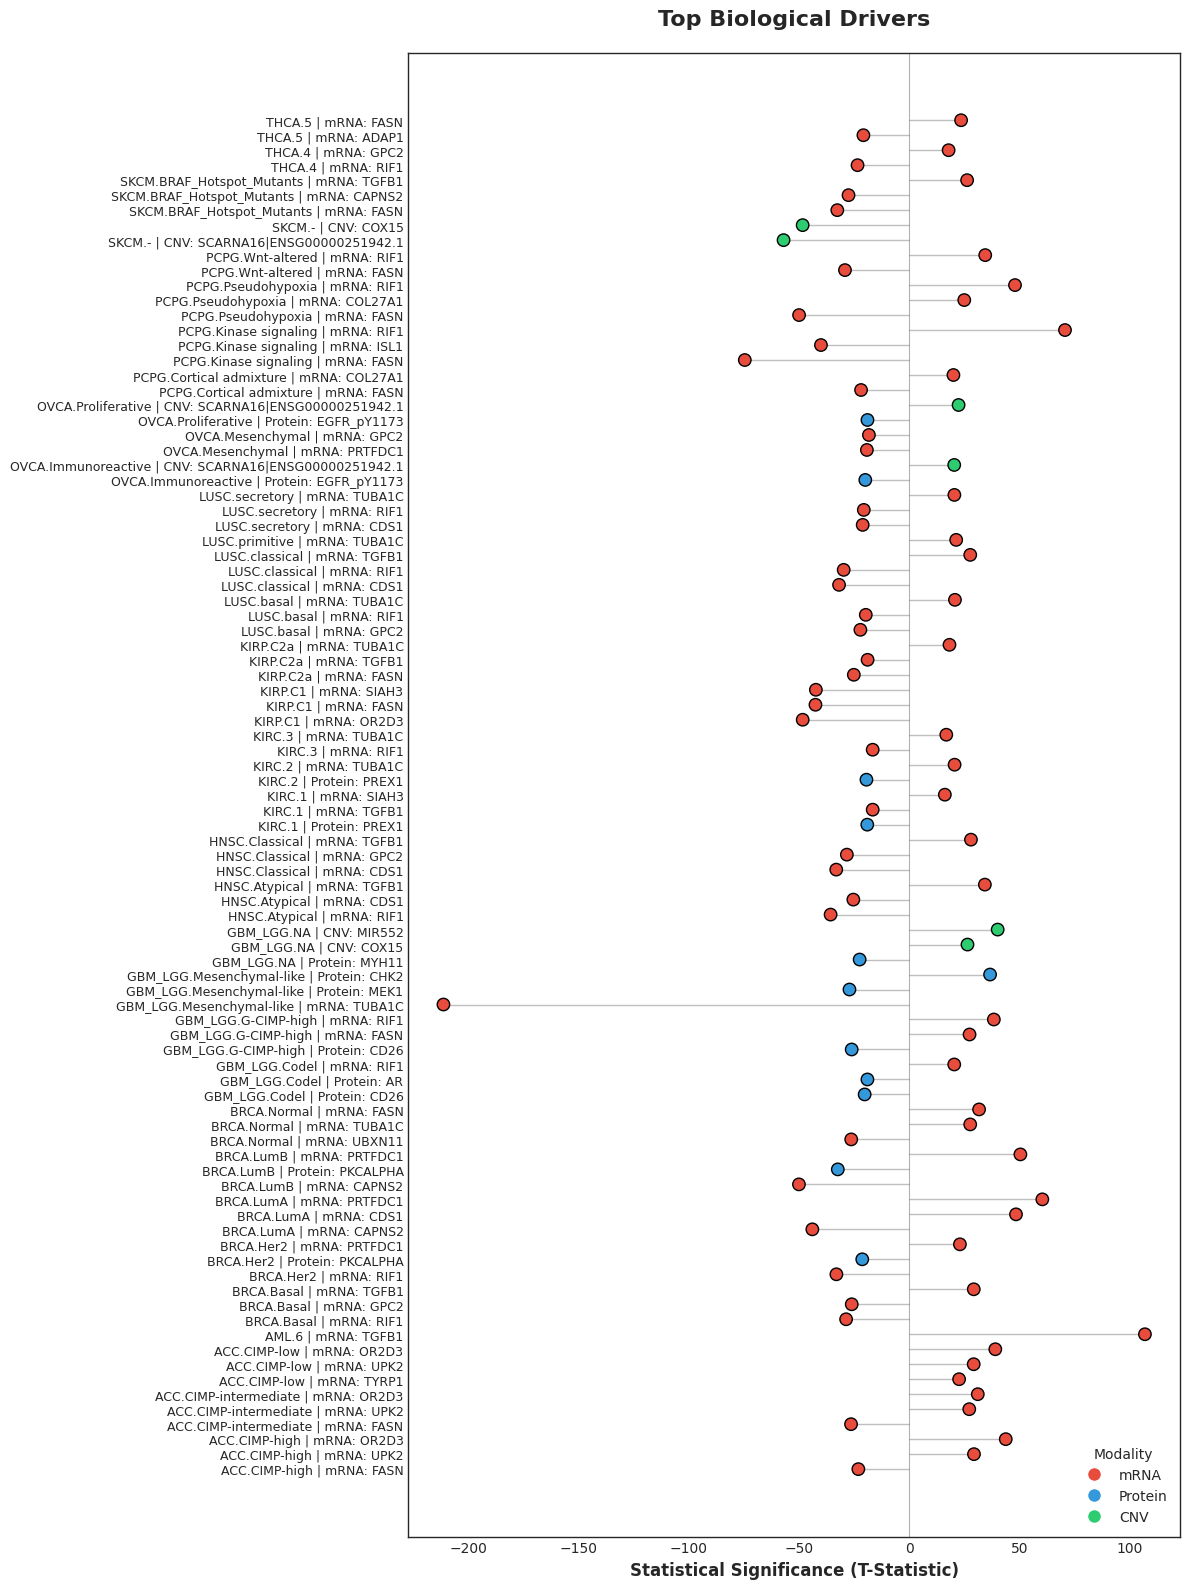

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the results
df = pd.read_csv('TEMPO_Top_Biological_Drivers.csv')

# --- 2. THE CLEANUP ---
# Remove any rows where the feature is a 'Mask'
df_clean = df[~df['Biological_Feature'].str.contains('Mask', case=False)].copy()

# Keep only the top 3 REAL biological features per cancer type
df_clean = df_clean.groupby('Cancer_Type').head(3)

# Shorten the names of PCA features for the plot
def shorten_pca(name):
    if 'Component' in name:
        # Simplifies "mRNA Component 3 (Top Gene: TGFB1)" -> "mRNA: TGFB1"
        parts = name.split(': ')
        if len(parts) > 1:
            modality = name.split(' ')[0]
            gene = parts[1].replace(')', '')
            return f"{modality}: {gene}"
    return name

df_clean['Short_Feature'] = df_clean['Biological_Feature'].apply(shorten_pca)
df_clean['Y_Label'] = df_clean['Cancer_Type'] + " | " + df_clean['Short_Feature']

# --- 3. THE PLOT ---
plt.figure(figsize=(12, 16)) # Very tall to prevent clustering
sns.set_style("ticks")

# Sort by Cancer Type then T-Stat
df_clean = df_clean.sort_values(['Cancer_Type', 'T_Stat'], ascending=[True, True])

# Create the Lollipop Plot
plt.hlines(y=range(len(df_clean)), xmin=0, xmax=df_clean['T_Stat'],
           color='gray', alpha=0.5, linewidth=1)

# Color dots by Modality for better insight
modality_colors = {
    'm': '#e74c3c', # Red for mRNA
    'P': '#3498db', # Blue for Protein
    'C': '#2ecc71'  # Green for CNV
}
colors = [modality_colors.get(f[0], 'gray') for f in df_clean['Short_Feature']]

plt.scatter(df_clean['T_Stat'], range(len(df_clean)),
            c=colors, s=80, edgecolors='black', zorder=3)

# Set Y-axis labels
plt.yticks(range(len(df_clean)), df_clean['Y_Label'], fontsize=9)

# Add Title and Labels
plt.title('Top Biological Drivers', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Statistical Significance (T-Statistic)', fontsize=12)
plt.axvline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)

# Add a legend for the colors
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='mRNA'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=10, label='Protein'),
                Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='CNV')]
plt.legend(handles=custom_lines, title="Modality", loc='lower right')

plt.tight_layout()
plt.savefig('TEMPO_Drivers_Cleaned.png', dpi=300)
print("✅ Cleaned biological plot saved as TEMPO_Drivers_Cleaned.png")

Looking at the visuals, TEMPO has sucessfully been able to differentiate between different cancer types using specific markers and has been proven to be interpetable. An interesting finding is how TEMPO prioritizes different modalities per cancer type. A even more interesting discovery is how commonly associated genes with cancer such as P53 are not dominating as driving genes. This means that TEMPO was able to look past the genes that are broadly associated with cancer in general and focus on specific genes/mutations associated with each individual subtype.

Most of TEMPO's findings are expected subtype-specific biomarkers, which is a good sign since it provides TEMPO validation. However, there are a few intriguing cross-context signals that could represent novel hypotheses such as:
- RIF1 as a pan-subtype discriminator across multiple cancers
- OR2D3 in ACC CIMP stratification
- FASN as a cross-lineage subtype axis rather than just overexpression marker
- Replication timing program as hidden organizing principle
- Role of COX15 in Melanoma